In [15]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage,ToolMessage
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode,tools_condition
from ddgs import DDGS
from langchain_core.tools import tool

from dotenv import load_dotenv
from typing import TypedDict,Annotated

import requests
import random
import json


In [16]:
load_dotenv()
llm = ChatOpenAI()

In [17]:
@tool
def search_tool(query: str) -> str:
    """DuckDuckGoSearchRun module to search any query over web and provide the response back."""
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=5)
        if not results:
            return "No results found."
        return "\n\n".join(
            f"Title: {r['title']}\nURL: {r['href']}\nSummary: {r['body']}"
            for r in results
        )
        
@tool
def calculator(first_number: float , second_number: float , operator: str) -> float:
    """Perform basic arithmetic operation on two numbers.
    Supported Operations are: add , sub, mul, div
    """
    if operator.lower() == "add":
        result = first_number + second_number
    elif operator.lower() == "sub":
        result = first_number - second_number
    elif operator.lower() == "mul":
        result = first_number * second_number
    elif operator.lower() == "div":
        if second_number == 0:
            return {"error" : "Division by Zero is not allowed."}
        result = first_number / second_number
    else:
        return {"error" : f"Unsupported arithmetic operation {operator}"}
        
    return {"first_number": first_number,"second_number": second_number,"operator": operator,"result" : result}

@tool
def get_stock_price(company_symbol:str) -> float:
    """Function to retrieve latest stock price for given company symbol"""
    url = f'https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={company_symbol}&apikey=S13EQQ9CISBBSGX6'
    
    result = requests.get(url).json()
    print(f"stock price: {result}")
    return result #{"company_symbol": company_symbol, "result": result}

In [18]:
tools = [search_tool,get_stock_price,calculator]

llm_with_tools = llm.bind_tools(tools)

In [19]:
class Chatstate(TypedDict):
    messages: Annotated[list[str],add_messages]

def call_llm(state: Chatstate) -> Chatstate:
    messages = state.get("messages")
    result =  llm_with_tools.invoke(messages)
    state["messages"] = result
    return state

def execute_tools(state: Chatstate) -> Chatstate:
    last_message = state.get("messages")[-1]
    tool_map = {t.name: t for t in tools}
    print(tool_map)
    
    results=[]
    for tool_call in last_message.tool_calls:
        tool_func = tool_map[tool_call["name"]]
        tool_output = tool_func.invoke(tool_call["args"])
        results.append(ToolMessage(content=tool_output,tool_call_id=tool_call["id"]))
    
    return {"messages" : results}

def condition_checks(state: Chatstate) -> Chatstate:
    last_messages = state.get("messages")[-1]
    
    if hasattr(last_messages,"tool_calls") and last_messages.tool_calls:
        return "execute_tools"
    
    return END

In [20]:
tool_node = ToolNode(tools)

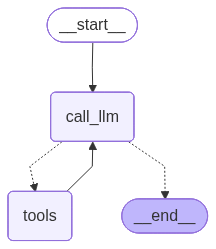

In [23]:
graph = StateGraph(Chatstate)

graph.add_node("call_llm",call_llm)
graph.add_node("tools",tool_node)

graph.add_edge(START,"call_llm")
graph.add_conditional_edges("call_llm",tools_condition)
graph.add_edge("tools","call_llm")

agent = graph.compile()
agent

In [ ]:
# graph = StateGraph(Chatstate)

# graph.add_node("call_llm",call_llm)
# graph.add_node("execute_tools",execute_tools)

# graph.add_edge(START,"call_llm")
# graph.add_conditional_edges("call_llm",condition_checks)
# graph.add_edge("execute_tools","call_llm")

# agent = graph.compile()

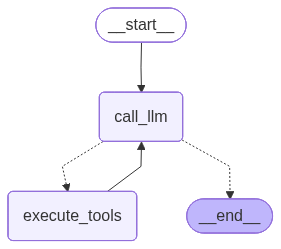

In [8]:
agent

In [24]:
initial_state = {"messages": [HumanMessage(content="what will be total amount if I have total 500 ORACLE shares?")]}

response = agent.invoke(initial_state)

stock price: {'Global Quote': {'01. symbol': 'ORCL', '02. open': '142.2000', '03. high': '142.8000', '04. low': '136.0000', '05. price': '137.8600', '06. volume': '30407824', '07. latest trading day': '2026-04-09', '08. previous close': '143.1408', '09. change': '-5.2808', '10. change percent': '-3.6893%'}}


In [25]:
print(response.get("messages")[-1].content)

The current stock price of ORACLE is $137.86 per share. 
To calculate the total amount for 500 ORACLE shares:
Total amount = 500 shares * $137.86/share = $68,930.
